In [2]:
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, I, Abs, re, im
from sympy.physics.control import *
import numpy as np
import matplotlib.pyplot as plt

# Funções Auxiliares

In [3]:
s, k = sp.symbols('s k')
ganho = k

## Função para receber coeficientes e transformar em polinômio

In [5]:
def polinomio(entrada):
    coeficientes = entrada.strip().split()  # Transforma a entrada em uma lista de strings e remove espaços extras
    coeficientes.reverse() # Inverte a lista
    lista_polinomio = []
    
    # Percorre de trás para frente para começar pelo maior expoente
    for exp in range(len(coeficientes) - 1, -1, -1):
        coef = coeficientes[exp]
        
        # Pula coeficientes que são zero
        if coef == "0":
            continue
            
        # Formata o termo dependendo do expoente
        if exp > 1:
            termo = f"{coef}*s**{exp}"
        elif exp == 1:
            termo = f"{coef}*s"
        else:
            termo = f"{coef}"
            
        lista_polinomio.append(termo)
        
    return " + ".join(lista_polinomio)


## Função para calcular passo 4

In [43]:
def lgr_real(polos, zeros):
    # Manter apenas polos e zeros reais
    for polo in polos:
        if(im(polo) != 0):
            polos.pop(polo)
    for zero in zeros:
        if(im(zero) != 0):
            zeros.pop(zero)

## Função para passo 07

In [6]:
def plot_assintotas(ax, ponto, angulos, comprimento=10):
    x0, y0 = ponto

    for angulo in angulos:
        theta = np.radians(angulo)

        x1 = x0 + comprimento * np.cos(theta)
        y1 = y0 + comprimento * np.sin(theta)

        ax.plot([x0, x1], [y0, y1], linestyle='--')

    ax.scatter(x0, y0, color='black', zorder=3, label = "sigma")
    ax.legend()


# Passo a passo LGR

In [92]:
print("Forneça os coeficientes da função G(s)...")
numerador_G = polinomio(input("Digite os coeficientes do numerador: "))
denominador_G = polinomio(input("Digite os coeficientes do denominador: "))

numerador_G = sp.parse_expr(numerador_G, local_dict={'s': s})
denominador_G = sp.parse_expr(denominador_G, local_dict={'s': s})

G = TransferFunction(numerador_G, denominador_G, s)
G

Forneça os coeficientes da função G(s)...


TransferFunction(s**2 + 8*s + 17, s**3 + 7*s**2 + 12*s + 10, s)

In [93]:
print("Forneça os coeficientes da função H(s)...")
numerador_H = polinomio(input("Digite os coeficientes do numerador: "))
denominador_H = polinomio(input("Digite os coeficientes do denominador: "))

numerador_H = sp.parse_expr(numerador_H, local_dict={'s': s})
denominador_H = sp.parse_expr(denominador_H, local_dict={'s': s})

H = TransferFunction(numerador_H, denominador_H, s)
H

Forneça os coeficientes da função H(s)...


TransferFunction(s + 1, s + 5, s)

In [94]:
ft = Series(G, H).doit()
sp.expand(ft.den)

s**4 + 12*s**3 + 47*s**2 + 70*s + 50

## Passo 01 - Escrever polinômio característico

In [95]:
print("1 + K*")
ft

1 + K*


TransferFunction((s + 1)*(s**2 + 8*s + 17), (s + 5)*(s**3 + 7*s**2 + 12*s + 10), s)

## Passo 02 = Fatorar polinômio - NÂO FATORA POLO COMPLEXO

In [97]:
fatorado = sp.factor(ft)
print("1 + K*")
fatorado

1 + K*


TransferFunction((s + 1)*(s**2 + 8*s + 17), (s + 5)**2*(s**2 + 2*s + 2), s)

# Passo 3 - Polos e Zeros de malha aberta

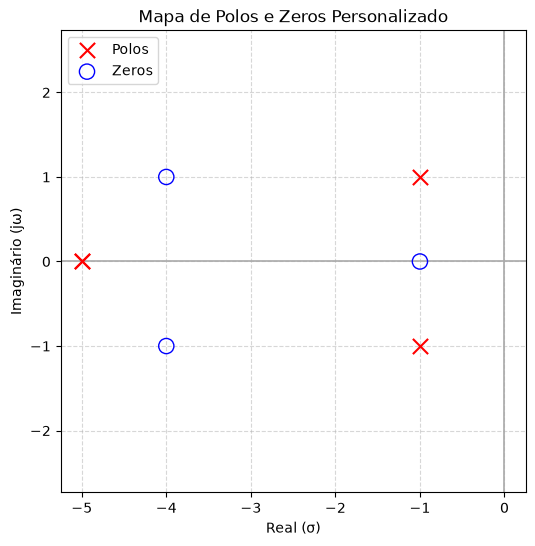

In [98]:
# 1. Extrai as coordenadas numéricas reais e imaginárias do SymPy
zeros, polos = pole_zero_numerical_data(fatorado)

def grafico_base():
    # 2. Cria o gráfico nativo no Matplotlib
    fig, ax = plt.subplots(figsize=(6, 6)) # Modificar limites 

    # Desenha os Polos (X vermelho) e Zeros (O azul)
    ax.scatter([p.real for p in polos], [p.imag for p in polos], 
            marker='x', color='red', s=120, label='Polos', zorder=3)
    ax.scatter([z.real for z in zeros], [z.imag for z in zeros], 
            marker='o', color='blue', facecolors='none', s=120, label='Zeros', zorder=3)

    ax.axhline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Real
    ax.axvline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Imaginário

    # Configurações visuais finais do gráfico
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('Real (σ)')
    ax.set_ylabel('Imaginário (jω)')
    ax.set_title('Mapa de Polos e Zeros Personalizado')
    ax.axis('equal') # Garante proporção 1:1 perfeita no plano complexo
    ax.legend()
    return ax


grafico_base()
plt.show()

## Passo 04 - Assinalar segmentos do eixo real LGR

In [99]:
def lgr_real(polos, zeros, grande = -20):
    # Manter apenas polos e zeros reais
    polos_reais = [polo for polo in polos if polo.imag == 0]
    zeros_reais = [zero for zero in zeros if zero.imag == 0]

    polos_zeros = polos_reais + zeros_reais
    polos_zeros.sort(reverse=True)
    i = 1
    linhas = []
    for ponto in polos_zeros:
        if(i % 2 == 1):
            inicio = ponto
        else:
            final = ponto
            linhas.append([inicio, final])
        i+=1
    if(i % 2 == 0): # Terminou com linha até o infinito
        linhas.append([inicio, grande])
    return linhas
lgr_real(polos, zeros)

[[-1.0, -5.0], [-5.0, -20]]

In [100]:
def passo04():
    ax = grafico_base()

    for linha in lgr_real(polos, zeros):
        ax.plot([linha[0], linha[1]], [0, 0], color = 'deeppink', label='Trecho do LGR') 

    plt.legend()
    return ax

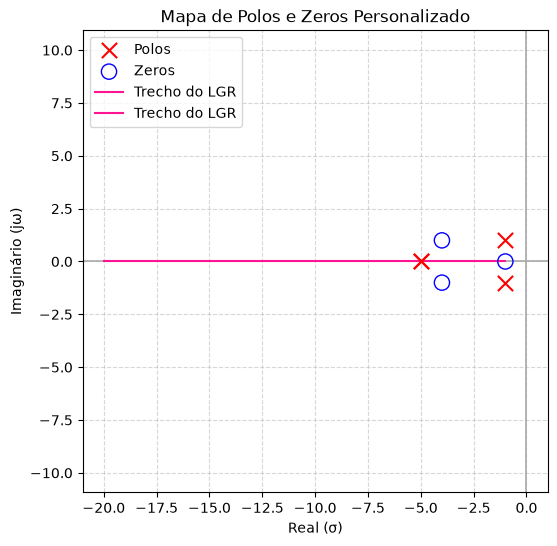

In [101]:
passo04()
plt.show()

## Passo 05 - Determinar número de lugares separados

In [103]:
n_polos = len(polos)
n_zeros = len(zeros)
if(n_polos >= n_zeros):
    ls = n_polos
else:
    ls = n_zeros
print(f"O número de lugares separados é {ls}")

O número de lugares separados é 4


## Passo 06 - LGR é simétrico em relação ao eixo real

## Passo 07 - Número de seguimentos LGR em direção a zeros infinitos

In [104]:
n_assintotas = n_polos - n_zeros

# Cálculo de sigma
soma_real = 0
for polo in polos:
    parte_real = re(polo)
    soma_real += parte_real
for zero in zeros:
    parte_real = re(zero)
    soma_real -= parte_real

sigma = soma_real/(n_polos - n_zeros)

#Cálculo do angulo das assintotas
angulos_assintotas = []
for q in range(n_polos - n_zeros): # 0, 1, 2, ..., (np - nz- 1)
    phi = (2*q + 1) *180/(n_polos - n_zeros)
    angulos_assintotas.append(phi)

In [105]:
print(f"{n_assintotas} assintotas para zeros infinitos")
print(f"As assintotas são centralizadas em {sigma}")
print(f"As assintotas tem ângulo: {angulos_assintotas}")

1 assintotas para zeros infinitos
As assintotas são centralizadas em -3.00000000000000
As assintotas tem ângulo: [180.0]


In [106]:
def passo07():
    ax = passo04()

    plot_assintotas(ax, (sigma, 0), angulos_assintotas, 10)
    return ax

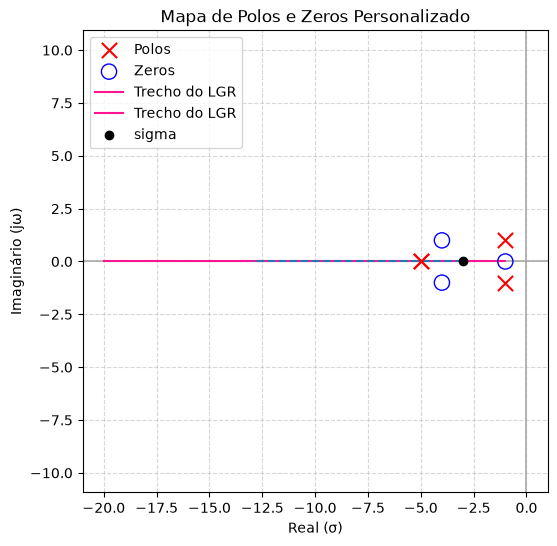

In [107]:
passo07()
plt.show()

## Passo 08 - Ponto de saída sobre o eixo real

In [108]:
# Inverso negativo: -1 / ft
# Converte o objeto de controle em uma expressão matemática comum do SymPy
ft_expressao = ft.to_expr()

# Agora você pode usar o sp.cancel() e fazer operações com números normalmente
ft_inverso_negativo = sp.cancel(-1 / ft_expressao)
ft_inverso_negativo

(-s**4 - 12*s**3 - 47*s**2 - 70*s - 50)/(s**3 + 9*s**2 + 25*s + 17)

In [109]:
df = sp.diff(ft_inverso_negativo, s)

raizes = sp.solve(df, s)
raizes_numericas = [complex(r.evalf()) for r in raizes]
raizes_numericas

[(-5+0j),
 (-3.3476095426040637+0j),
 (-1.8895914059319256+0j),
 (0.0770436012026979+0j),
 (-3.919921326333354-3.042576823753013j),
 (-3.919921326333354+3.042576823753013j)]

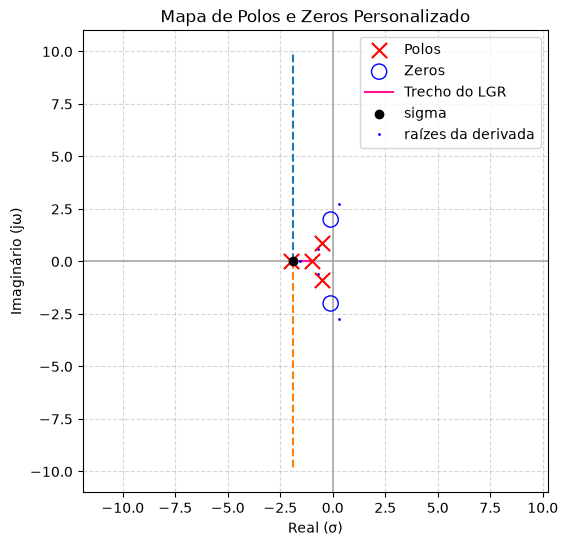

In [87]:
ax = passo07()

x = [r.real for r in raizes_numericas]
y = [r.imag for r in raizes_numericas]

ax.plot(x, y, 'b.', markersize=2, label = "raízes da derivada")

plt.legend()
plt.show()

In [88]:
ponto_saida = []
linhas = lgr_real(polos, zeros)

for raiz in raizes_numericas:
    if im(raiz) == 0:
        for linha in linhas:
            if re(raiz) > linha[1] and re(raiz) < linha[0]:
               ponto_saida.append(raiz)
ponto_saida

[(-1.5790357168380098+0j)]

## Passo 09 - Usar Routh-Hurwirtz para determinar cruzamento com eixo imaginário

In [50]:
coeficientes_den = sp.Poly(sp.expand(ft.den), s).all_coeffs()
coeficientes_den[len(coeficientes_den) -1] = coeficientes_den[len(coeficientes_den) -1] + k

if len(coeficientes_den) %2 == 1:
    coeficientes_den.append(0)

routh_hurwitz = []
linha_1 = coeficientes_den[::2]
linha_2 = coeficientes_den[1::2]
routh_hurwitz.append(linha_1)
routh_hurwitz.append(linha_2)

for linha in routh_hurwitz:
    print(linha)

linha_3 = []
i = 0
print(routh_hurwitz[i+1][i],routh_hurwitz[i][i+1],routh_hurwitz[i][i],routh_hurwitz[i+1][i+1])


[1, 64, k]
[12, 128, 0]
12 64 1 128


## Passo 10 - Ângulo de partida para polos complexos e ângulo de chegada para zeros complexos